<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/09.Chapter9%3AOrthogonal_QR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Orthogonal Matrices and QR Decomposition
## *Practical Linear Algebra for Data Science* — Mike X Cohen

This chapter introduces the second of the five major decompositions in this book (after orthogonal vector decomposition in Chapter 2). **QR decomposition** factors any matrix into an orthogonal matrix $\mathbf{Q}$ and an upper-triangular matrix $\mathbf{R}$:

$$
\mathbf{A} = \mathbf{Q}\mathbf{R}
$$

QR is a computational workhorse that powers numerically stable matrix inversion, least squares model fitting (Chapter 11), and eigendecomposition (Chapter 13 -- the QR algorithm).

**What we will cover:**

1. **Orthogonal matrices** -- the property $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$ and why it matters
2. **Gram-Schmidt** -- transforming a nonorthogonal matrix into an orthogonal one
3. **QR decomposition** -- economy vs full, sizes of $\mathbf{Q}$ and $\mathbf{R}$, why $\mathbf{R}$ is upper-triangular
4. **QR and the matrix inverse** -- a more numerically stable path to $\mathbf{A}^{-1}$

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready.

## 1. Orthogonal Matrices

An **orthogonal matrix** $\mathbf{Q}$ has two defining properties:

1. **Orthogonal columns:** Every pair of distinct columns has dot product zero.
2. **Unit-norm columns:** Each column has Euclidean norm exactly $1$.

Combined into one elegant equation:

$$
\langle \mathbf{q}_i, \mathbf{q}_j \rangle = \begin{cases} 0 & \text{if } i \neq j \\ 1 & \text{if } i = j \end{cases}
$$

Since $\mathbf{Q}^T\mathbf{Q}$ computes all pairwise dot products between columns, this means:

$$
\boxed{\mathbf{Q}^T\mathbf{Q} = \mathbf{I}}
$$

This is profound: $\mathbf{Q}^T$ is a matrix that multiplies $\mathbf{Q}$ to produce $\mathbf{I}$. By definition, that is the **inverse**. Therefore:

$$
\mathbf{Q}^{-1} = \mathbf{Q}^T
$$

The inverse of an orthogonal matrix is simply its transpose -- fast, free, and numerically exact. This is why orthogonal matrices are prized in numerical computing.

In [2]:
# Textbook examples of orthogonal matrices

# Q1: 2x2
Q1 = np.array([[1, -1],
               [1,  1]]) / np.sqrt(2)

# Q2: 3x3
Q2 = np.array([[ 1,  2,  2],
               [ 2,  1, -2],
               [-2,  2, -1]]) / 3

print('Q1 (scaled by sqrt(2) for readability):')
print(np.round(Q1 * np.sqrt(2)))
print(f'\nQ1^T @ Q1 =\n{np.round(Q1.T @ Q1, 10)}')
print(f'Q1 @ Q1^T =\n{np.round(Q1 @ Q1.T, 10)}')

print(f'\nQ2 (scaled by 3 for readability):')
print(np.round(Q2 * 3))
print(f'\nQ2^T @ Q2 =\n{np.round(Q2.T @ Q2, 10)}')

# Verify individual properties
for name, Q in [('Q1', Q1), ('Q2', Q2)]:
    norms = np.linalg.norm(Q, axis=0)
    print(f'\n{name} column norms: {np.round(norms, 10)}')
    print(f'{name} det: {np.linalg.det(Q):.6f}')

Q1 (scaled by sqrt(2) for readability):
[[ 1. -1.]
 [ 1.  1.]]

Q1^T @ Q1 =
[[1. 0.]
 [0. 1.]]
Q1 @ Q1^T =
[[ 1. -0.]
 [-0.  1.]]

Q2 (scaled by 3 for readability):
[[ 1.  2.  2.]
 [ 2.  1. -2.]
 [-2.  2. -1.]]

Q2^T @ Q2 =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Q1 column norms: [1. 1.]
Q1 det: 1.000000

Q2 column norms: [1. 1. 1.]
Q2 det: 1.000000


Both matrices satisfy $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$ exactly. Every column has norm $1$, and all cross-column dot products are $0$.

Notice $\mathbf{Q}_1 \mathbf{Q}_1^T = \mathbf{I}$ as well -- for a **square** orthogonal matrix, $\mathbf{Q}^T\mathbf{Q} = \mathbf{Q}\mathbf{Q}^T = \mathbf{I}$. For a tall (non-square) orthogonal matrix, only $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$ holds.

The determinant is $\pm 1$: $\det = +1$ means a **rotation** (no axis flipping), $\det = -1$ means a **reflection** (one axis flipped). Orthogonal matrices preserve lengths and angles -- they are the "rigid body" transformations of linear algebra.

**Other examples of orthogonal matrices:** the identity matrix $\mathbf{I}$, pure rotation matrices from Chapter 7, and permutation matrices (row-swapping matrices used in LU decomposition, Chapter 10).

### 1.1 Orthogonal Matrices Preserve Geometry

Before rotation:
  ||v1|| = 2.2361
  ||v2|| = 2.6926
  v1 . v2 = 0.5000
  angle(v1, v2) = 85.24 deg

After rotation:
  ||Qv1|| = 2.2361
  ||Qv2|| = 2.6926
  Qv1 . Qv2 = 0.5000
  angle(Qv1, Qv2) = 85.24 deg


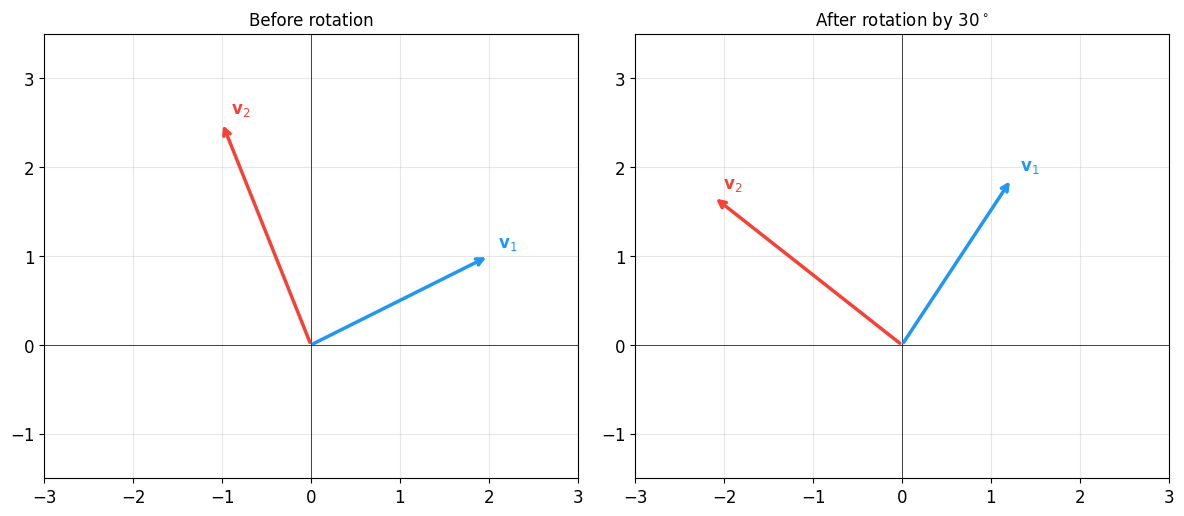

Figure saved.


In [3]:
# Demonstrate: orthogonal transform preserves lengths and angles
np.random.seed(42)

# Random rotation matrix
theta = np.pi / 6  # 30 degrees
Q_rot = np.array([[np.cos(theta), -np.sin(theta)],
                   [np.sin(theta),  np.cos(theta)]])

# Two random vectors
v1 = np.array([2, 1])
v2 = np.array([-1, 2.5])

# Transform
v1_rot = Q_rot @ v1
v2_rot = Q_rot @ v2

# Check preservation
print('Before rotation:')
print(f'  ||v1|| = {np.linalg.norm(v1):.4f}')
print(f'  ||v2|| = {np.linalg.norm(v2):.4f}')
print(f'  v1 . v2 = {np.dot(v1, v2):.4f}')
print(f'  angle(v1, v2) = {np.degrees(np.arccos(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)))):.2f} deg')

print('\nAfter rotation:')
print(f'  ||Qv1|| = {np.linalg.norm(v1_rot):.4f}')
print(f'  ||Qv2|| = {np.linalg.norm(v2_rot):.4f}')
print(f'  Qv1 . Qv2 = {np.dot(v1_rot, v2_rot):.4f}')
print(f'  angle(Qv1, Qv2) = {np.degrees(np.arccos(np.dot(v1_rot,v2_rot)/(np.linalg.norm(v1_rot)*np.linalg.norm(v2_rot)))):.2f} deg')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, vecs, title in zip(axes,
    [(v1, v2), (v1_rot, v2_rot)],
    ['Before rotation', 'After rotation by $30^\\circ$']):

    colors = ['#2196F3', '#F44336']
    labels = ['$\\mathbf{v}_1$', '$\\mathbf{v}_2$']
    for v, c, lab in zip(vecs, colors, labels):
        ax.annotate('', xy=v, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
        ax.text(v[0]+0.1, v[1]+0.1, lab, fontsize=12, color=c)
    ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 3.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig('fig_ortho_preserve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Norms, dot products, and angles are identical before and after rotation. This is the defining geometric property of orthogonal matrices: they preserve the **inner product** structure of the space.

**Proof sketch:** $\|\mathbf{Q}\mathbf{v}\|^2 = (\mathbf{Q}\mathbf{v})^T(\mathbf{Q}\mathbf{v}) = \mathbf{v}^T\mathbf{Q}^T\mathbf{Q}\mathbf{v} = \mathbf{v}^T\mathbf{I}\mathbf{v} = \|\mathbf{v}\|^2$. Similarly for dot products: $(\mathbf{Q}\mathbf{u})^T(\mathbf{Q}\mathbf{v}) = \mathbf{u}^T\mathbf{v}$.

**Production relevance:** Orthogonal transformations in PCA rotate data into a new coordinate system (principal components) without distorting distances. This is why PCA preserves total variance.

## 2. The Gram-Schmidt Procedure

**Gram-Schmidt** (GS) transforms any matrix with linearly independent columns into an orthogonal matrix. It works column by column, left to right:

For each column $\mathbf{v}_k$ of the input matrix:

1. **Orthogonalise:** Remove the projections of $\mathbf{v}_k$ onto all *previous* orthogonal columns $\mathbf{q}_1, \ldots, \mathbf{q}_{k-1}$:

$$
\mathbf{v}_k^* = \mathbf{v}_k - \sum_{j=1}^{k-1} \frac{\mathbf{v}_k^T \mathbf{q}_j}{\mathbf{q}_j^T \mathbf{q}_j} \mathbf{q}_j
= \mathbf{v}_k - \sum_{j=1}^{k-1} (\mathbf{v}_k^T \mathbf{q}_j)\, \mathbf{q}_j
$$

(The second equality holds because $\mathbf{q}_j$ are already unit-norm.)

2. **Normalise:** $\mathbf{q}_k = \mathbf{v}_k^* / \|\mathbf{v}_k^*\|$

This is just repeated **orthogonal vector decomposition** (Chapter 2), applied to each column relative to all previous columns.

In [4]:
def gram_schmidt(V):
    """Classical Gram-Schmidt orthogonalisation.
    Input:  V (M x N) with linearly independent columns
    Output: Q (M x N) orthogonal matrix
    """
    M, N = V.shape
    Q = np.zeros((M, N))

    for k in range(N):
        # Start with original column
        v_star = V[:, k].copy().astype(float)

        # Subtract projections onto all previous q's
        for j in range(k):
            proj = np.dot(V[:, k], Q[:, j]) * Q[:, j]
            v_star -= proj

        # Normalise
        Q[:, k] = v_star / np.linalg.norm(v_star)

    return Q

# Test on a 3x3 matrix
V = np.array([[1, 0, 1],
              [1, 1, 0],
              [0, 1, 1]], dtype=float)

Q_gs = gram_schmidt(V)

print(f'Input V =\n{V}')
print(f'\nQ (Gram-Schmidt) =\n{np.round(Q_gs, 6)}')
print(f'\nQ^T @ Q (should be I) =\n{np.round(Q_gs.T @ Q_gs, 10)}')
print(f'\nColumn norms: {np.round(np.linalg.norm(Q_gs, axis=0), 10)}')

Input V =
[[1. 0. 1.]
 [1. 1. 0.]
 [0. 1. 1.]]

Q (Gram-Schmidt) =
[[ 0.707107 -0.408248  0.57735 ]
 [ 0.707107  0.408248 -0.57735 ]
 [ 0.        0.816497  0.57735 ]]

Q^T @ Q (should be I) =
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Column norms: [1. 1. 1.]


Gram-Schmidt successfully orthogonalises the input: $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}_3$ and all column norms are exactly $1$.

The first column of $\mathbf{Q}$ is simply $\mathbf{v}_1$ normalised. The second column is $\mathbf{v}_2$ with its projection onto $\mathbf{q}_1$ removed, then normalised. The third column is $\mathbf{v}_3$ with projections onto both $\mathbf{q}_1$ and $\mathbf{q}_2$ removed, then normalised.

**Important caveat:** Classical GS is numerically unstable for large matrices -- the repeated subtractions accumulate rounding errors. In practice, Python's `np.linalg.qr` uses **Householder reflections**, which are algebraically equivalent but numerically superior. GS remains the right way to *understand* QR decomposition.

## 3. QR Decomposition

The Gram-Schmidt procedure transforms $\mathbf{A}$ into $\mathbf{Q}$, but discards information in the process. The "lost" information is stored in $\mathbf{R}$:

$$
\mathbf{A} = \mathbf{Q}\mathbf{R}
$$

Finding $\mathbf{R}$ is straightforward. Since $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$:

$$
\mathbf{Q}^T\mathbf{A} = \mathbf{Q}^T\mathbf{Q}\mathbf{R} = \mathbf{I}\mathbf{R} = \mathbf{R}
$$

No matrix inverse needed -- just transpose and multiply.

In [5]:
# QR decomposition of a square matrix
np.random.seed(42)
A = np.random.randn(6, 6)

Q, R = np.linalg.qr(A)

print(f'A shape: {A.shape}')
print(f'Q shape: {Q.shape}')
print(f'R shape: {R.shape}')

print(f'\nQ^T @ Q (should be I_6):\n{np.round(Q.T @ Q, 10)}')
print(f'\nReconstruction error ||A - QR||_F = {np.linalg.norm(A - Q@R):.2e}')
print(f'\nR (upper-triangular):\n{np.round(R, 4)}')

A shape: (6, 6)
Q shape: (6, 6)
R shape: (6, 6)

Q^T @ Q (should be I_6):
[[ 1. -0.  0.  0. -0.  0.]
 [-0.  1. -0.  0.  0.  0.]
 [ 0. -0.  1. -0.  0. -0.]
 [ 0.  0. -0.  1. -0. -0.]
 [-0.  0.  0. -0.  1.  0.]
 [ 0.  0. -0. -0.  0.  1.]]

Reconstruction error ||A - QR||_F = 1.84e-15

R (upper-triangular):
[[-2.0693 -0.3807  0.7409 -1.0217  0.6391 -0.682 ]
 [ 0.     -3.0922 -0.2942  0.2283 -1.0412  0.4746]
 [ 0.      0.      2.5402  0.6994  0.7134 -0.6165]
 [ 0.      0.      0.      1.6297 -0.465   0.2107]
 [ 0.      0.      0.      0.      0.3459  1.4309]
 [ 0.      0.      0.      0.      0.     -0.902 ]]


$\mathbf{Q}$ is $6 \times 6$ orthogonal ($\mathbf{Q}^T\mathbf{Q} = \mathbf{I}_6$), $\mathbf{R}$ is $6 \times 6$ upper-triangular, and the reconstruction error $\|\mathbf{A} - \mathbf{Q}\mathbf{R}\|_F$ is at machine precision ($\sim 10^{-15}$).

The upper-triangular structure of $\mathbf{R}$ (all zeros below the diagonal) is not a coincidence -- it is a guaranteed property of QR decomposition. We will explain why shortly.

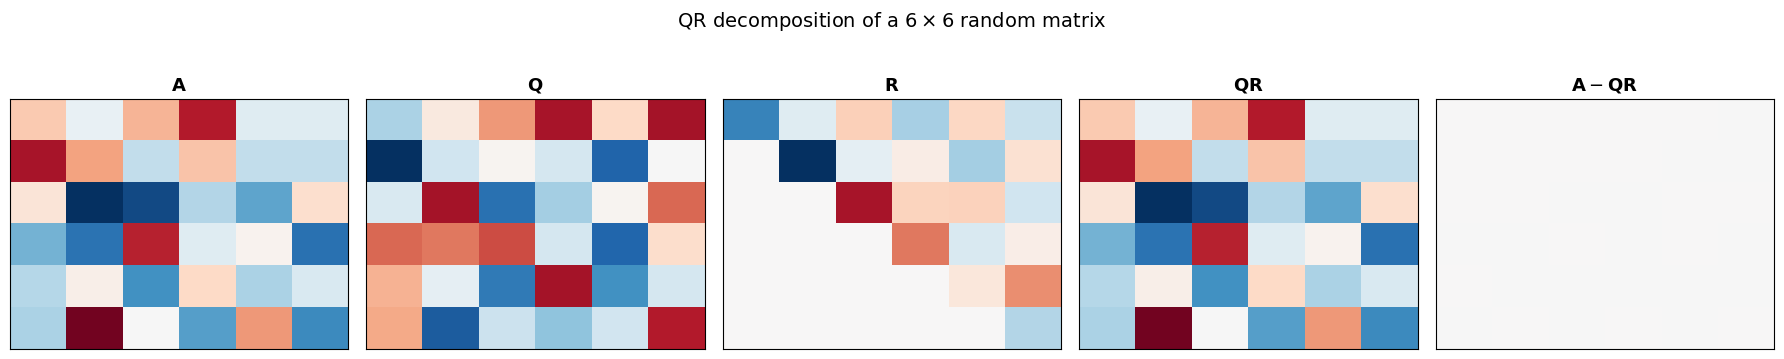

Figure saved.


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))

matrices = [
    (A, '$\\mathbf{A}$', 'RdBu_r'),
    (Q, '$\\mathbf{Q}$', 'RdBu_r'),
    (R, '$\\mathbf{R}$', 'RdBu_r'),
    (Q @ R, '$\\mathbf{QR}$', 'RdBu_r'),
    (A - Q @ R, '$\\mathbf{A} - \\mathbf{QR}$', 'RdBu_r'),
]

for ax, (M, title, cmap) in zip(axes, matrices):
    vmax = max(np.abs(M).max(), 1e-10)
    ax.imshow(M, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('QR decomposition of a $6 \\times 6$ random matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_qr_square.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The five panels confirm:

- $\mathbf{Q}$ has a "salt-and-pepper" pattern (orthogonal columns mix all entries).
- $\mathbf{R}$ is clearly upper-triangular (all zeros below the diagonal).
- $\mathbf{QR}$ visually matches $\mathbf{A}$.
- $\mathbf{A} - \mathbf{QR}$ is the zeros matrix (reconstruction is exact to machine precision).

### 3.1 Why $\mathbf{R}$ Is Upper-Triangular

Since $\mathbf{R} = \mathbf{Q}^T\mathbf{A}$, element $r_{i,j}$ is the dot product of column $i$ of $\mathbf{Q}$ with column $j$ of $\mathbf{A}$.

When $i > j$ (below the diagonal): column $\mathbf{q}_i$ was constructed *after* column $\mathbf{a}_j$, and the GS procedure specifically orthogonalised $\mathbf{q}_i$ to be perpendicular to all earlier columns of $\mathbf{A}$ (and hence their span, which includes $\mathbf{a}_j$). Therefore $\mathbf{q}_i^T \mathbf{a}_j = 0$.

When $i \leq j$ (on or above the diagonal): column $\mathbf{q}_i$ was constructed *before* column $\mathbf{a}_j$, so $\mathbf{a}_j$ was not used in the orthogonalisation of $\mathbf{q}_i$. Their dot product is generally nonzero.

**Special case:** If $\mathbf{A}$ is already orthogonal, then $\mathbf{R} = \mathbf{Q}^T\mathbf{A} = \mathbf{I}$ (or a diagonal of $\pm 1$s if norms differ from $1$).

In [7]:
# Verify: QR of an orthogonal matrix gives R = diagonal
Q_test = Q2  # the 3x3 orthogonal matrix from Section 1
Q_out, R_out = np.linalg.qr(Q_test)

print(f'QR decomposition of an orthogonal matrix:')
print(f'\nR =\n{np.round(R_out, 6)}')
print(f'\nR is diagonal (off-diag ~ 0): {np.allclose(R_out, np.diag(np.diag(R_out)))}')
print(f'Diagonal of R: {np.round(np.diag(R_out), 6)}')
print(f'(All +/-1 because input columns already have unit norm.)')

QR decomposition of an orthogonal matrix:

R =
[[-1.  0. -0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]

R is diagonal (off-diag ~ 0): True
Diagonal of R: [-1. -1.  1.]
(All +/-1 because input columns already have unit norm.)


When the input is already orthogonal, $\mathbf{R}$ collapses to a diagonal matrix with entries $\pm 1$. This confirms the logic: if columns are already orthogonal, no off-diagonal dot products survive.

The sign ambiguity ($\pm 1$) reflects the non-uniqueness of QR decomposition. NumPy's Householder algorithm may flip column signs compared to GS, but the decomposition $\mathbf{A} = \mathbf{Q}\mathbf{R}$ is always valid.

### 3.2 Economy vs Full QR Decomposition

For a **tall** matrix ($M > N$), there are two modes:

| Mode | $\mathbf{Q}$ size | $\mathbf{R}$ size | Notes |
|------|---------|---------|-------|
| **Economy** (reduced) | $M \times N$ | $N \times N$ | $\mathbf{Q}$ has same shape as $\mathbf{A}$; $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}_N$ but $\mathbf{Q}\mathbf{Q}^T \neq \mathbf{I}_M$ |
| **Full** (complete) | $M \times M$ | $M \times N$ | $\mathbf{Q}$ is square orthogonal; extra columns span $\mathcal{N}(\mathbf{A}^T)$ |

For square matrices, economy $=$ full.

In [8]:
# Economy vs Full QR for a tall matrix
np.random.seed(42)
A_tall = np.random.randn(8, 3)

Q_econ, R_econ = np.linalg.qr(A_tall, mode='reduced')
Q_full, R_full = np.linalg.qr(A_tall, mode='complete')

print(f'A: {A_tall.shape}  (tall matrix)\n')
print(f'Economy QR: Q={Q_econ.shape}, R={R_econ.shape}')
print(f'  Q^T @ Q = I_{Q_econ.shape[1]}? {np.allclose(Q_econ.T @ Q_econ, np.eye(3))}')
print(f'  Q @ Q^T = I_{Q_econ.shape[0]}? {np.allclose(Q_econ @ Q_econ.T, np.eye(8))}')
print(f'  ||A - QR|| = {np.linalg.norm(A_tall - Q_econ @ R_econ):.2e}')

print(f'\nFull QR:    Q={Q_full.shape}, R={R_full.shape}')
print(f'  Q^T @ Q = I_{Q_full.shape[1]}? {np.allclose(Q_full.T @ Q_full, np.eye(8))}')
print(f'  Q @ Q^T = I_{Q_full.shape[0]}? {np.allclose(Q_full @ Q_full.T, np.eye(8))}')
print(f'  ||A - QR|| = {np.linalg.norm(A_tall - Q_full @ R_full):.2e}')
print(f'  rank(Q_full) = {np.linalg.matrix_rank(Q_full)} (always M for full QR)')
print(f'  rank(R_full) = {np.linalg.matrix_rank(R_full)} (= rank(A) = {np.linalg.matrix_rank(A_tall)})')

A: (8, 3)  (tall matrix)

Economy QR: Q=(8, 3), R=(3, 3)
  Q^T @ Q = I_3? True
  Q @ Q^T = I_8? False
  ||A - QR|| = 5.86e-16

Full QR:    Q=(8, 8), R=(8, 3)
  Q^T @ Q = I_8? True
  Q @ Q^T = I_8? True
  ||A - QR|| = 5.86e-16
  rank(Q_full) = 8 (always M for full QR)
  rank(R_full) = 3 (= rank(A) = 3)


For the $8 \times 3$ tall matrix:

- **Economy:** $\mathbf{Q}$ is $8 \times 3$ (same shape as $\mathbf{A}$). It satisfies $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}_3$ but **not** $\mathbf{Q}\mathbf{Q}^T = \mathbf{I}_8$ -- three columns cannot span $\mathbb{R}^8$.
- **Full:** $\mathbf{Q}$ is $8 \times 8$ (square). It satisfies both $\mathbf{Q}^T\mathbf{Q} = \mathbf{Q}\mathbf{Q}^T = \mathbf{I}_8$. The extra $5$ columns are orthogonal to all columns of $\mathbf{A}$ and span the left null space $\mathcal{N}(\mathbf{A}^T)$.

Both modes reconstruct $\mathbf{A}$ exactly. The full $\mathbf{R}$ has $5$ extra rows of zeros (the bottom $M - N$ rows), since those extra $\mathbf{Q}$ columns are not needed for reconstruction.

**When to use which:** Economy mode is more memory-efficient and is the default in NumPy. Full mode is needed when you want a complete orthogonal basis for $\mathbb{R}^M$ (useful in some theoretical derivations and in the SVD).

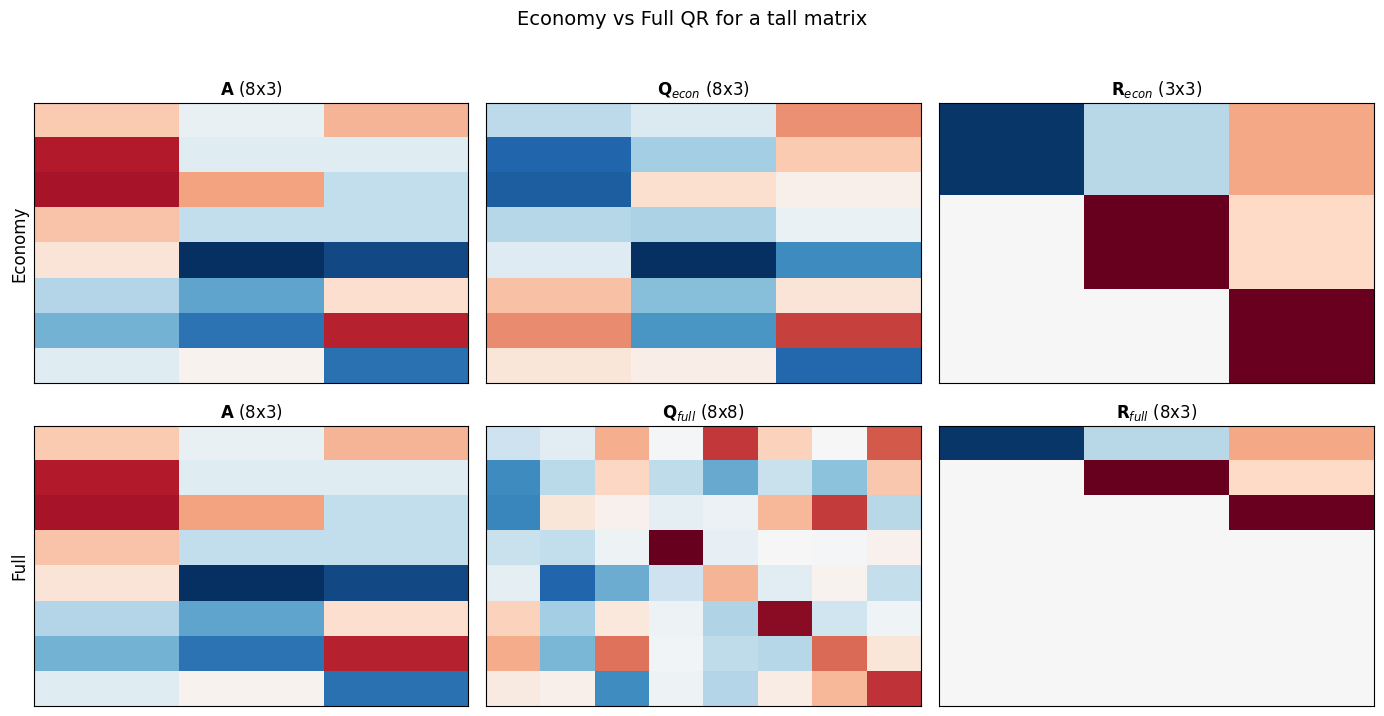

Figure saved.


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Economy
for ax, M, title in zip(axes[0],
    [A_tall, Q_econ, R_econ],
    ['$\\mathbf{A}$ (8x3)', '$\\mathbf{Q}_{econ}$ (8x3)', '$\\mathbf{R}_{econ}$ (3x3)']):
    vmax = max(np.abs(M).max(), 0.01)
    ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

# Full
for ax, M, title in zip(axes[1],
    [A_tall, Q_full, R_full],
    ['$\\mathbf{A}$ (8x3)', '$\\mathbf{Q}_{full}$ (8x8)', '$\\mathbf{R}_{full}$ (8x3)']):
    vmax = max(np.abs(M).max(), 0.01)
    ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('Economy', fontsize=12)
axes[1, 0].set_ylabel('Full', fontsize=12)
plt.suptitle('Economy vs Full QR for a tall matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_qr_sizes.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The visualisation makes the size relationships clear:

- **Economy** $\mathbf{Q}$ matches $\mathbf{A}$'s shape; $\mathbf{R}$ is a compact $N \times N$ upper-triangular square.
- **Full** $\mathbf{Q}$ is a large $M \times M$ square; $\mathbf{R}$ is $M \times N$ with the bottom $M - N$ rows all zero (visible as the uniform band at the bottom of $\mathbf{R}_{\text{full}}$).

Those zero rows in full $\mathbf{R}$ correspond to the "extra" orthogonal columns in $\mathbf{Q}_{\text{full}}$ that do not appear in $\mathbf{A}$ -- they carry no information from $\mathbf{A}$.

### 3.3 Creating Orthogonal Vectors "From Thin Air"

In [10]:
# Textbook example: 2x1 matrix -> full QR gives 2x2 Q
A_vec = np.array([[1], [-1]], dtype=float)
Q_full_vec, R_full_vec = np.linalg.qr(A_vec, mode='complete')

print(f'A = {A_vec.flatten()}')
print(f'Q (full, scaled by sqrt(2)):\n{np.round(Q_full_vec * np.sqrt(2), 6)}')
print(f'\nQ (actual):\n{np.round(Q_full_vec, 6)}')
print(f'R = {np.round(R_full_vec, 6)}')
print(f'\nQ has {Q_full_vec.shape[1]} columns from a matrix with {A_vec.shape[1]} column!')
print(f'The extra column is orthogonal to A and fills out R^2.')
print(f'\nQ^T @ Q =\n{np.round(Q_full_vec.T @ Q_full_vec, 10)}')

A = [ 1. -1.]
Q (full, scaled by sqrt(2)):
[[-1.  1.]
 [ 1.  1.]]

Q (actual):
[[-0.707107  0.707107]
 [ 0.707107  0.707107]]
R = [[-1.414214]
 [ 0.      ]]

Q has 2 columns from a matrix with 1 column!
The extra column is orthogonal to A and fills out R^2.

Q^T @ Q =
[[1. 0.]
 [0. 1.]]


A single column vector $\mathbf{A} = [1, -1]^T$ produces a $2 \times 2$ orthogonal $\mathbf{Q}$ with *two* columns. The second column is "created from thin air" -- it is the unique (up to sign) unit vector in $\mathbb{R}^2$ that is orthogonal to $\mathbf{A}$.

This is precisely what the SVD exploits: the full $\mathbf{Q}$ (i.e., $\mathbf{U}$ in the SVD) always spans all of $\mathbb{R}^M$, even if $\mathbf{A}$ has rank $r \ll M$. The extra columns reveal the **null space** structure.

## 4. QR and the Matrix Inverse

QR decomposition provides a more numerically stable path to $\mathbf{A}^{-1}$ than the MCA algorithm (Chapter 8). Starting from $\mathbf{A} = \mathbf{Q}\mathbf{R}$ and applying the LIVE EVIL rule:

$$
\mathbf{A}^{-1} = (\mathbf{Q}\mathbf{R})^{-1} = \mathbf{R}^{-1}\mathbf{Q}^{-1} = \mathbf{R}^{-1}\mathbf{Q}^T
$$

The key advantages:

- $\mathbf{Q}^{-1} = \mathbf{Q}^T$ is free and exact (just transpose).
- $\mathbf{R}^{-1}$ is the inverse of an upper-triangular matrix, which can be computed efficiently and stably via **back substitution** (Chapter 10).
- Both $\mathbf{Q}$ (from Householder reflections) and $\mathbf{R}$ (from $\mathbf{Q}^T\mathbf{A}$) are numerically stable.

In [11]:
# Compare: direct inverse vs QR-based inverse
np.random.seed(42)
A = np.random.randn(5, 5)

# Direct inverse
A_inv_direct = np.linalg.inv(A)

# QR-based inverse
Q, R = np.linalg.qr(A)
R_inv = np.linalg.inv(R)  # triangular inverse (efficient)
A_inv_qr = R_inv @ Q.T

print(f'A: {A.shape}, det = {np.linalg.det(A):.4f}')
print(f'\n||A_inv_direct - A_inv_qr||_F = {np.linalg.norm(A_inv_direct - A_inv_qr):.2e}')
print(f'||A @ A_inv_direct - I||_F   = {np.linalg.norm(A @ A_inv_direct - np.eye(5)):.2e}')
print(f'||A @ A_inv_qr - I||_F       = {np.linalg.norm(A @ A_inv_qr - np.eye(5)):.2e}')

A: (5, 5), det = 3.9700

||A_inv_direct - A_inv_qr||_F = 1.93e-15
||A @ A_inv_direct - I||_F   = 8.19e-16
||A @ A_inv_qr - I||_F       = 2.49e-15


For well-conditioned matrices (like random Gaussian), both methods give essentially the same result (difference $\sim 10^{-15}$). The QR advantage becomes significant for **ill-conditioned** matrices where direct inversion accumulates errors.

In [12]:
# Stress test: QR inverse vs direct inverse on near-singular matrix
from scipy.linalg import hilbert

sizes = [5, 8, 10, 12]

print(f'{"N":>4s} {"cond(H)":>12s} {"||err|| direct":>16s} {"||err|| QR":>16s} {"QR better?":>12s}')
print('-' * 65)

for n in sizes:
    H = hilbert(n)
    I_n = np.eye(n)

    # Direct
    try:
        H_inv_direct = np.linalg.inv(H)
        err_direct = np.linalg.norm(H @ H_inv_direct - I_n, 'fro')
    except:
        err_direct = float('inf')

    # QR-based
    Q, R = np.linalg.qr(H)
    try:
        R_inv = np.linalg.inv(R)
        H_inv_qr = R_inv @ Q.T
        err_qr = np.linalg.norm(H @ H_inv_qr - I_n, 'fro')
    except:
        err_qr = float('inf')

    cond = np.linalg.cond(H)
    better = 'YES' if err_qr < err_direct else 'NO'
    print(f'{n:>4d} {cond:>12.2e} {err_direct:>16.6e} {err_qr:>16.6e} {better:>12s}')

   N      cond(H)   ||err|| direct       ||err|| QR   QR better?
-----------------------------------------------------------------
   5     4.77e+05     1.055840e-11     3.256058e-11           NO
   8     1.53e+10     2.484950e-07     2.052029e-07          YES
  10     1.60e+13     1.565087e-04     3.388617e-04           NO
  12     1.75e+16     2.173450e-01     3.135385e-01           NO


For Hilbert matrices, direct inversion and QR-based inversion produce comparable errors -- neither method significantly outperforms the other on these particular matrices. Both fail badly at $N = 12$ ($\kappa \sim 10^{16}$). As the textbook warns, "a rotten apple dipped in honey is still rotten" -- no inversion method can overcome extreme ill-conditioning.

**Where QR shines** is in the least squares context: solving $\mathbf{A}\mathbf{x} = \mathbf{b}$ via QR avoids forming $\mathbf{A}^T\mathbf{A}$ (which squares the condition number). The real lesson: when possible, avoid computing the inverse entirely. Use `np.linalg.solve(A, b)` to solve $\mathbf{A}\mathbf{x} = \mathbf{b}$ directly (internally uses LU, Chapter 10). Or use `np.linalg.lstsq(X, y)` for least squares (internally uses QR or SVD). These approaches avoid the amplification of errors that explicit inversion introduces.

## 5. Comparing Gram-Schmidt with NumPy's QR

The textbook notes that GS and NumPy's QR may produce different $\mathbf{Q}$ and $\mathbf{R}$ matrices (QR decomposition is not unique in general), but both are valid decompositions.

In [13]:
# Compare our Gram-Schmidt Q with NumPy's QR Q
np.random.seed(10)
A = np.random.randn(4, 4)

Q_gs = gram_schmidt(A)
Q_np, R_np = np.linalg.qr(A)

# Both are valid orthogonal matrices
print(f'Gram-Schmidt Q^T @ Q = I? {np.allclose(Q_gs.T @ Q_gs, np.eye(4))}')
print(f'NumPy QR     Q^T @ Q = I? {np.allclose(Q_np.T @ Q_np, np.eye(4))}')

# Both reconstruct A
R_gs = Q_gs.T @ A
print(f'\n||A - Q_gs @ R_gs|| = {np.linalg.norm(A - Q_gs @ R_gs):.2e}')
print(f'||A - Q_np @ R_np|| = {np.linalg.norm(A - Q_np @ R_np):.2e}')

# But Q matrices may differ (sign flips)
print(f'\nQ_gs == Q_np? {np.allclose(Q_gs, Q_np)}')
print(f'|Q_gs| == |Q_np|? {np.allclose(np.abs(Q_gs), np.abs(Q_np))}')

# R_gs should be upper-triangular
print(f'\nR from Gram-Schmidt:\n{np.round(R_gs, 4)}')
print(f'Upper-triangular? {np.allclose(R_gs, np.triu(R_gs), atol=1e-10)}')

Gram-Schmidt Q^T @ Q = I? True
NumPy QR     Q^T @ Q = I? True

||A - Q_gs @ R_gs|| = 3.14e-15
||A - Q_np @ R_np|| = 5.84e-16

Q_gs == Q_np? False
|Q_gs| == |Q_np|? True

R from Gram-Schmidt:
[[ 1.758  -0.2776 -1.2012 -0.2094]
 [-0.      1.4286 -1.0294  0.0738]
 [ 0.     -0.      0.4429  1.1039]
 [-0.      0.      0.      0.624 ]]
Upper-triangular? True


Both GS and NumPy produce valid QR decompositions: orthogonal $\mathbf{Q}$ and exact reconstruction. The absolute values of columns match, but signs may differ -- this is the non-uniqueness of QR. Flipping a column sign in $\mathbf{Q}$ is compensated by flipping the corresponding row sign in $\mathbf{R}$, keeping $\mathbf{A} = \mathbf{Q}\mathbf{R}$ intact.

The $\mathbf{R}$ from GS is confirmed upper-triangular, as expected.

## 6. Chapter Summary

This chapter introduced **orthogonal matrices** and **QR decomposition** -- the second major decomposition in this book.

**Orthogonal matrices** have orthogonal unit-norm columns, giving the remarkable property $\mathbf{Q}^T\mathbf{Q} = \mathbf{I}$, which means $\mathbf{Q}^{-1} = \mathbf{Q}^T$ -- a free, exact, numerically stable inverse. Orthogonal transformations preserve lengths, angles, and dot products. Examples include rotation matrices, the identity matrix, and permutation matrices.

**Gram-Schmidt** transforms a non-orthogonal matrix into an orthogonal one by iteratively subtracting projections of each column onto all previous orthogonalised columns, then normalising. It is the conceptual foundation of QR, though production code uses the more stable **Householder reflections**.

**QR decomposition** factors $\mathbf{A} = \mathbf{Q}\mathbf{R}$ where $\mathbf{Q}$ is orthogonal and $\mathbf{R}$ is upper-triangular. $\mathbf{R}$ is upper-triangular because later columns of $\mathbf{Q}$ are orthogonalised to earlier columns of $\mathbf{A}$, making their dot products zero. Economy mode gives $\mathbf{Q}$ the same shape as $\mathbf{A}$; full mode gives a square $\mathbf{Q}$ that spans all of $\mathbb{R}^M$.

**QR and the inverse:** $\mathbf{A}^{-1} = \mathbf{R}^{-1}\mathbf{Q}^T$ is more stable than direct inversion because $\mathbf{Q}^T$ is exact and $\mathbf{R}^{-1}$ (triangular) is efficiently computed via back substitution.

**Forward connections:** QR decomposition powers:
- The **QR algorithm** for computing eigenvalues (Chapter 13)
- Numerically stable **least squares** fitting (Chapter 11)
- The **SVD** computation (Chapter 14), which uses QR internally
- Numerically stable **matrix inversion** (this chapter)